# Day 3 — EDA Charts: Visualising SQL Findings

## Objective
Translate the 8 SQL findings from Day 2 into 5 professional charts.
Each chart is designed around one specific insight, not just data display.
All charts saved to `charts/` as PNG files for use in the README and Power BI.

## Charts
1. Monthly SLA breach rate trend (with spike annotations)
2. Breach severity breakdown (donut + bar)
3. Seller vs carrier delivery time split
4. Top 10 seller states by breach rate
5. Breach rate by order value tier

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Chart style — consistent with Project 1
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load clean dataset
df = pd.read_csv('../data/clean/orders_clean.csv', parse_dates=['order_purchase_timestamp'])

print(f"Loaded: {df.shape[0]:,} rows | {df.shape[1]} columns")
print(f"Date range: {df['order_purchase_timestamp'].min().date()} "
      f"to {df['order_purchase_timestamp'].max().date()}")
print(f"Overall breach rate: {df['sla_breached'].mean()*100:.2f}%")

Loaded: 96,470 rows | 28 columns
Date range: 2016-09-15 to 2018-08-29
Overall breach rate: 6.77%


## Chart 1 — Monthly SLA Breach Rate Trend

**Insight being visualised:** SLA performance has improved overall but
suffered two significant spikes November 2017 (12.40%) and March 2018
(18.96%), both coinciding with peak order volume periods.

**Design decisions:**
- Area fill under the line emphasises the magnitude of spikes visually
- Annotations mark the two anomalous months so the reader doesn't have
  to hunt for them
- Platform average shown as a dashed reference line
- Months with fewer than 100 orders excluded (2016-09, 2016-12),
  single-digit order counts produce statistically meaningless rates

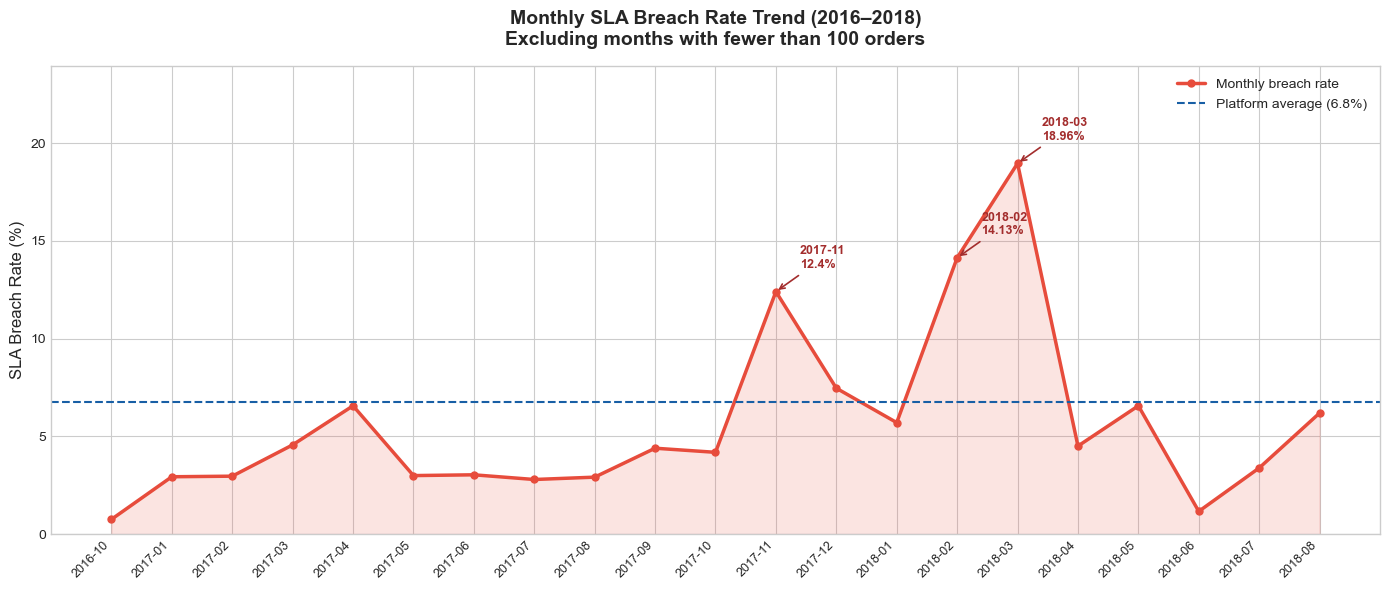

Chart 1 saved ✅
Peak month: 2018-03 — 18.96%
Best month: 2016-10 — 0.75%


In [2]:
fig, ax = plt.subplots(figsize=(14, 6))

# Build monthly summary
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly = (df.groupby('year_month')
             .agg(total_orders=('sla_breached','count'),
                  breached=('sla_breached','sum'))
             .reset_index())
monthly['breach_rate'] = (monthly['breached'] / monthly['total_orders'] * 100).round(2)
monthly['year_month_str'] = monthly['year_month'].astype(str)

# Exclude months with fewer than 100 orders (statistically unreliable)
monthly = monthly[monthly['total_orders'] >= 100].reset_index(drop=True)

# Plot line + area fill
ax.fill_between(range(len(monthly)), monthly['breach_rate'],
                alpha=0.15, color='#E74C3C')
ax.plot(range(len(monthly)), monthly['breach_rate'],
        color='#E74C3C', linewidth=2.5, marker='o',
        markersize=5, label='Monthly breach rate')

# Platform average reference line
platform_avg = df['sla_breached'].mean() * 100
ax.axhline(y=platform_avg, color='#185FA5', linestyle='--',
           linewidth=1.5, label=f'Platform average ({platform_avg:.1f}%)')

# Annotate the two spike months
spikes = monthly[monthly['breach_rate'] > 10]
for _, row in spikes.iterrows():
    idx = monthly[monthly['year_month_str'] == row['year_month_str']].index[0]
    ax.annotate(f"{row['year_month_str']}\n{row['breach_rate']}%",
                xy=(idx, row['breach_rate']),
                xytext=(idx + 0.4, row['breach_rate'] + 1.2),
                fontsize=9, fontweight='bold', color='#A32D2D',
                arrowprops=dict(arrowstyle='->', color='#A32D2D', lw=1.2))

# X axis labels — show every 3rd month to avoid crowding
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['year_month_str'],
                   rotation=45, ha='right', fontsize=9)
ax.set_ylabel('SLA Breach Rate (%)', fontsize=12)
ax.set_title('Monthly SLA Breach Rate Trend (2016–2018)\n'
             'Excluding months with fewer than 100 orders',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.set_ylim(0, monthly['breach_rate'].max() + 5)

plt.tight_layout()
plt.savefig('../charts/01_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved ✅")
print(f"Peak month: {monthly.loc[monthly['breach_rate'].idxmax(), 'year_month_str']} "
      f"— {monthly['breach_rate'].max()}%")
print(f"Best month: {monthly.loc[monthly['breach_rate'].idxmin(), 'year_month_str']} "
      f"— {monthly['breach_rate'].min()}%")

## Chart 2 — Breach Severity Breakdown

**Insight being visualised:** The 6.77% headline breach rate understates
the problem. Nearly half of breaches are severe (7+ days late), averaging
19.6 days late a genuine customer experience failure, not a cosmetic delay.

**Design decisions:**
- Donut chart shows proportions of ALL orders (on time vs breach tiers)
- Bar chart shows absolute counts of breached orders only
- Side by side lets the reader answer both "what fraction" and "how many"
- Colour progression: green (on time) → yellow → orange → red (severe)

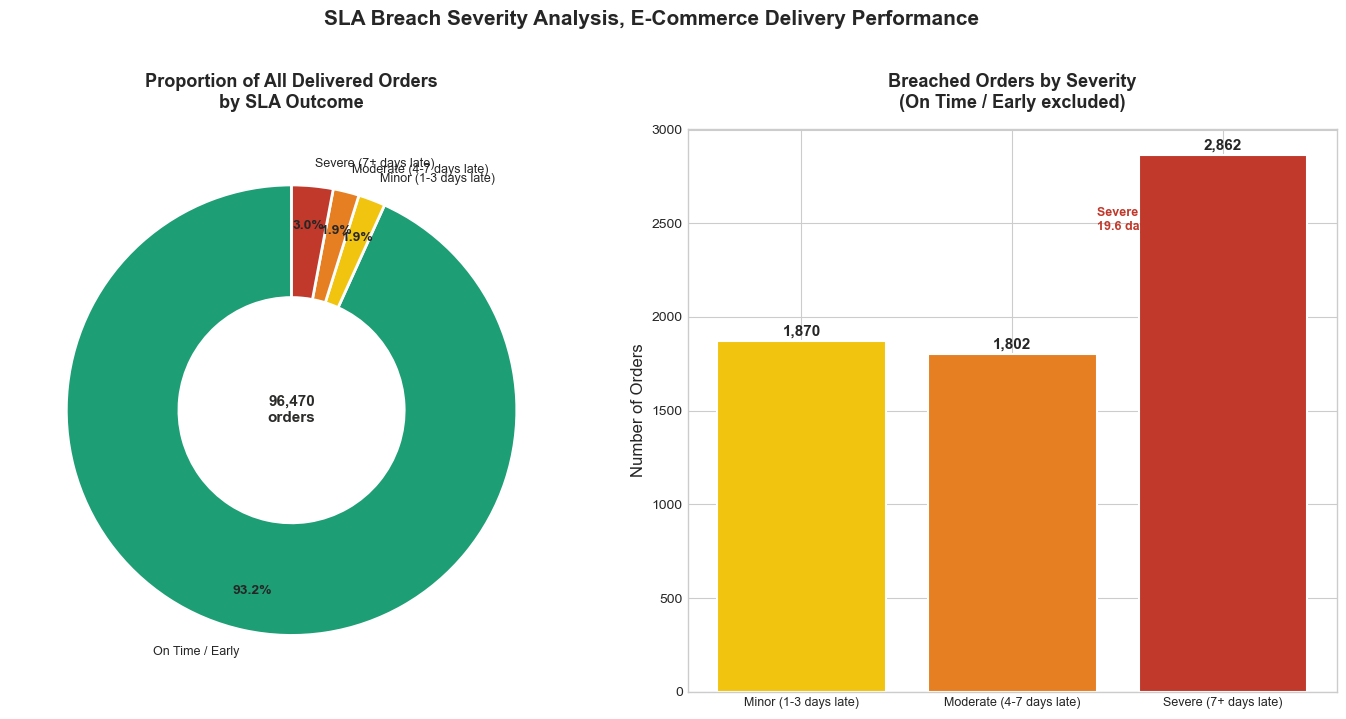

Chart 2 saved ✅

Severity breakdown:
                severity  count
         On Time / Early  89936
   Minor (1-3 days late)   1870
Moderate (4-7 days late)   1802
   Severe (7+ days late)   2862


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Define order and colours — green to red progression
severity_order = [
    'On Time / Early',
    'Minor (1-3 days late)',
    'Moderate (4-7 days late)',
    'Severe (7+ days late)'
]
colors = ['#1D9E75', '#F1C40F', '#E67E22', '#C0392B']

severity_counts = (df['breach_severity']
                     .value_counts()
                     .reindex(severity_order)
                     .reset_index())
severity_counts.columns = ['severity', 'count']

# ── Left: Donut chart (all orders) ──────────────────────────────────────────
wedges, texts, autotexts = axes[0].pie(
    severity_counts['count'],
    labels=severity_counts['severity'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight('bold')
for t in texts:
    t.set_fontsize(9)

axes[0].set_title('Proportion of All Delivered Orders\nby SLA Outcome',
                  fontsize=13, fontweight='bold', pad=15)

# Add total orders in donut centre
axes[0].text(0, 0, f'{len(df):,}\norders',
             ha='center', va='center', fontsize=11, fontweight='bold',
             color='#2C2C2A')

# ── Right: Bar chart (breached orders only) ──────────────────────────────────
breached_only = severity_counts[severity_counts['severity'] != 'On Time / Early']
bars = axes[1].bar(breached_only['severity'], breached_only['count'],
                   color=colors[1:], edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, breached_only['count']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')

axes[1].set_ylabel('Number of Orders', fontsize=12)
axes[1].set_title('Breached Orders by Severity\n(On Time / Early excluded)',
                  fontsize=13, fontweight='bold', pad=15)
axes[1].tick_params(axis='x', labelsize=9)

# Add platform context annotation
severe_count = severity_counts[
    severity_counts['severity'] == 'Severe (7+ days late)'
]['count'].values[0]
axes[1].annotate(f'Severe breaches avg\n19.6 days late',
                 xy=(2, severe_count), xytext=(1.4, severe_count - 400),
                 fontsize=9, color='#C0392B', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.2))

plt.suptitle('SLA Breach Severity Analysis, E-Commerce Delivery Performance',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../charts/02_severity_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved ✅")
print(f"\nSeverity breakdown:")
print(severity_counts.to_string(index=False))

## Chart 3 — Seller vs Carrier Delivery Time Split

**Insight being visualised:** Carrier delivery accounts for 73% of total
delivery time overall, but on breached orders, carrier time is 3.6x longer
than on on-time orders (27.4 vs 7.5 days). Seller processing doubles on
breached orders too (5.6 vs 2.5 days), but the carrier gap is the dominant
driver of severe breaches.

**Design decisions:**
- Grouped bar chart comparing on-time vs breached orders side by side
- Separates seller and carrier components clearly
- Annotation highlights the 3.6x carrier gap, the key finding

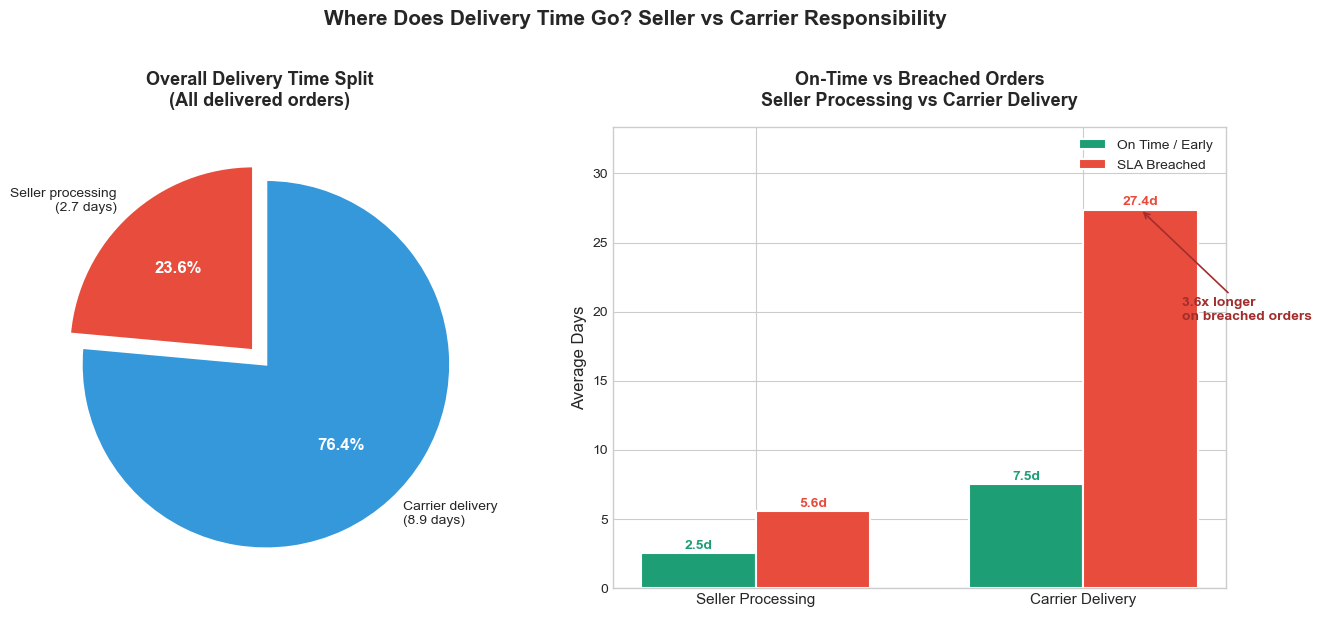

Chart 3 saved ✅

Overall split:
  Seller: 2.74 days (23.6%)
  Carrier: 8.88 days (76.4%)

On-time orders:  seller 2.53d | carrier 7.53d
Breached orders: seller 5.59d | carrier 27.39d
Carrier ratio:   3.6x longer on breached orders


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Overall split (pie) ─────────────────────────────────────────────
overall = df[['seller_processing_days','carrier_delivery_days']].dropna()
avg_seller  = overall['seller_processing_days'].mean()
avg_carrier = overall['carrier_delivery_days'].mean()

labels  = ['Seller processing\n(2.7 days)', 'Carrier delivery\n(8.9 days)']
sizes   = [avg_seller, avg_carrier]
colors_pie = ['#E74C3C', '#3498DB']
explode = (0.05, 0.05)

wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=colors_pie, explode=explode,
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight('bold')
    t.set_color('white')

axes[0].set_title('Overall Delivery Time Split\n(All delivered orders)',
                  fontsize=13, fontweight='bold', pad=15)

# ── Right: Grouped bar — on time vs breached ─────────────────────────────
on_time  = df[df['sla_breached'] == 0][['seller_processing_days',
                                         'carrier_delivery_days']].dropna()
breached = df[df['sla_breached'] == 1][['seller_processing_days',
                                         'carrier_delivery_days']].dropna()

categories  = ['Seller Processing', 'Carrier Delivery']
ontime_vals = [on_time['seller_processing_days'].mean(),
               on_time['carrier_delivery_days'].mean()]
breach_vals = [breached['seller_processing_days'].mean(),
               breached['carrier_delivery_days'].mean()]

x     = range(len(categories))
width = 0.35

bars1 = axes[1].bar([i - width/2 for i in x], ontime_vals,
                    width, label='On Time / Early',
                    color='#1D9E75', edgecolor='white', linewidth=1.5)
bars2 = axes[1].bar([i + width/2 for i in x], breach_vals,
                    width, label='SLA Breached',
                    color='#E74C3C', edgecolor='white', linewidth=1.5)

# Value labels on bars
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}d',
                 ha='center', fontsize=10, fontweight='bold',
                 color='#1D9E75')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}d',
                 ha='center', fontsize=10, fontweight='bold',
                 color='#E74C3C')

# Annotate the 3.6x carrier gap
carrier_ratio = round(breach_vals[1] / ontime_vals[1], 1)
axes[1].annotate(f'{carrier_ratio}x longer\non breached orders',
                 xy=(1 + width/2, breach_vals[1]),
                 xytext=(1.3, breach_vals[1] - 8),
                 fontsize=10, color='#A32D2D', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#A32D2D', lw=1.2))

axes[1].set_ylabel('Average Days', fontsize=12)
axes[1].set_title('On-Time vs Breached Orders\nSeller Processing vs Carrier Delivery',
                  fontsize=13, fontweight='bold', pad=15)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(categories, fontsize=11)
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, max(breach_vals) + 6)

plt.suptitle('Where Does Delivery Time Go? Seller vs Carrier Responsibility',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../charts/03_seller_vs_carrier.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved ✅")
print(f"\nOverall split:")
print(f"  Seller: {avg_seller:.2f} days ({avg_seller/(avg_seller+avg_carrier)*100:.1f}%)")
print(f"  Carrier: {avg_carrier:.2f} days ({avg_carrier/(avg_seller+avg_carrier)*100:.1f}%)")
print(f"\nOn-time orders:  seller {ontime_vals[0]:.2f}d | carrier {ontime_vals[1]:.2f}d")
print(f"Breached orders: seller {breach_vals[0]:.2f}d | carrier {breach_vals[1]:.2f}d")
print(f"Carrier ratio:   {carrier_ratio}x longer on breached orders")

## Chart 4 — Breach Rate by Seller State

**Insight being visualised:** SLA underperformance is geographically
concentrated. Only 3 of 13 states exceed the platform average MA is
a significant outlier at 19.07%, and SP drives the most absolute breached
orders due to its dominant volume (71% of all orders).

**Design decisions:**
- Horizontal bar chart state names are long, horizontal labels are cleaner
- Two-colour scheme: red for states above platform average, teal for below
- Platform average dashed line for immediate reference
- Secondary annotation showing absolute breach count for SP volume context
- Minimum 100 orders filter applied (consistent with Q5 SQL)

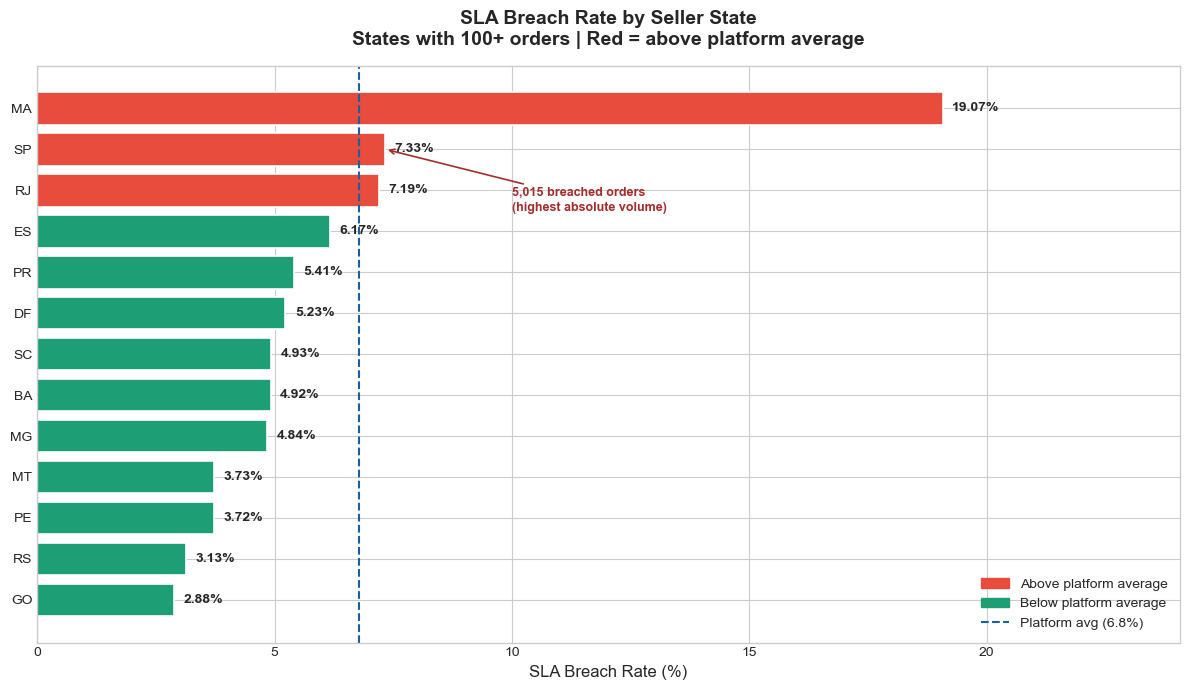

Chart 4 saved ✅

States above platform average (6.8%):
seller_state  total_orders  breached  breach_rate
          RJ          4185       301         7.19
          SP         68415      5015         7.33
          MA           388        74        19.07


In [6]:
fig, ax = plt.subplots(figsize=(12, 7))

# Build state summary
state_summary = (df[df['seller_state'].notna()]
                   .groupby('seller_state')
                   .agg(total_orders=('sla_breached','count'),
                        breached=('sla_breached','sum'))
                   .reset_index())
state_summary['breach_rate'] = (
    state_summary['breached'] / state_summary['total_orders'] * 100
).round(2)

# Apply 100-order minimum filter
state_summary = state_summary[state_summary['total_orders'] >= 100]
state_summary = state_summary.sort_values('breach_rate', ascending=True)

platform_avg = df['sla_breached'].mean() * 100

# Colour: red if above platform average, teal if below
colors = ['#E74C3C' if x > platform_avg else '#1D9E75'
          for x in state_summary['breach_rate']]

bars = ax.barh(state_summary['seller_state'],
               state_summary['breach_rate'],
               color=colors, edgecolor='white', linewidth=1.2)

# Value labels
for bar, val in zip(bars, state_summary['breach_rate']):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10, fontweight='bold')

# Platform average line
ax.axvline(x=platform_avg, color='#185FA5', linestyle='--',
           linewidth=1.5, label=f'Platform average ({platform_avg:.1f}%)')

# Annotate SP with absolute breach count
sp_row = state_summary[state_summary['seller_state'] == 'SP']
if len(sp_row) > 0:
    sp_breached = sp_row['breached'].values[0]
    sp_y = list(state_summary['seller_state']).index('SP')
    ax.annotate(f'{sp_breached:,} breached orders\n(highest absolute volume)',
                xy=(sp_row['breach_rate'].values[0], sp_y),
                xytext=(10, sp_y - 1.5),
                fontsize=9, color='#A32D2D', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#A32D2D', lw=1.2))

ax.set_xlabel('SLA Breach Rate (%)', fontsize=12)
ax.set_title('SLA Breach Rate by Seller State\n'
             'States with 100+ orders | Red = above platform average',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.set_xlim(0, state_summary['breach_rate'].max() + 5)

# Legend patches
above = mpatches.Patch(color='#E74C3C', label='Above platform average')
below = mpatches.Patch(color='#1D9E75', label='Below platform average')
avg_line = plt.Line2D([0],[0], color='#185FA5', linestyle='--',
                       linewidth=1.5, label=f'Platform avg ({platform_avg:.1f}%)')
ax.legend(handles=[above, below, avg_line], fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig('../charts/04_breach_by_state.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved ✅")
print(f"\nStates above platform average ({platform_avg:.1f}%):")
above_avg = state_summary[state_summary['breach_rate'] > platform_avg]
print(above_avg[['seller_state','total_orders','breached','breach_rate']].to_string(index=False))

## Chart 5 — Breach Rate by Order Value Tier

**Insight being visualised:** Counterintuitively, higher value orders
breach SLA more frequently than cheap orders. Premium orders (R$500+)
breach at 8.09% vs 6.01% for low-value orders the platform's most
valuable customers receive the worst delivery experience.

**Design decisions:**
- Simple bar chart four tiers, one metric, no complexity needed
- Colour gradient from teal (best) to red (worst) encodes performance visually
- Platform average reference line shows which tiers are above/below
- Average order value annotated on each bar shows the commercial stakes
- This is the most counterintuitive finding in the project design keeps it clean
  so the number speaks for itself

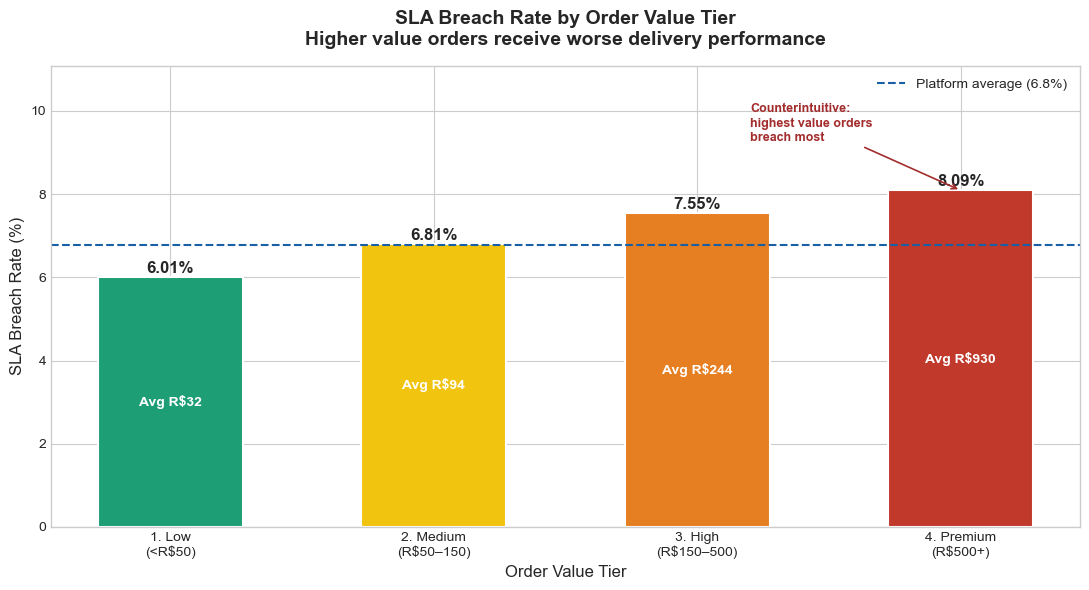

Chart 5 saved ✅

Value tier summary:
           value_tier  total_orders  breach_rate  avg_order_value
      1. Low\n(<R$50)         28790         6.01        31.835561
2. Medium\n(R$50–150)         44086         6.81        94.146445
 3. High\n(R$150–500)         20094         7.55       243.776189
 4. Premium\n(R$500+)          3500         8.09       929.921200

Platform average: 6.77%


In [7]:
fig, ax = plt.subplots(figsize=(11, 6))

# Build value tier summary
def value_tier(price):
    if pd.isna(price):    return None
    elif price < 50:      return '1. Low\n(<R$50)'
    elif price < 150:     return '2. Medium\n(R$50–150)'
    elif price < 500:     return '3. High\n(R$150–500)'
    else:                 return '4. Premium\n(R$500+)'

df['value_tier'] = df['total_price'].apply(value_tier)

tier_summary = (df[df['value_tier'].notna()]
                  .groupby('value_tier')
                  .agg(total_orders=('sla_breached','count'),
                       breached=('sla_breached','sum'),
                       avg_order_value=('total_price','mean'))
                  .reset_index())
tier_summary['breach_rate'] = (
    tier_summary['breached'] / tier_summary['total_orders'] * 100
).round(2)
tier_summary = tier_summary.sort_values('value_tier')

platform_avg = df['sla_breached'].mean() * 100

# Colour gradient: teal → yellow → orange → red
colors = ['#1D9E75', '#F1C40F', '#E67E22', '#C0392B']

bars = ax.bar(tier_summary['value_tier'],
              tier_summary['breach_rate'],
              color=colors, edgecolor='white',
              linewidth=1.5, width=0.55)

# Breach rate labels on top of bars
for bar, val in zip(bars, tier_summary['breach_rate']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{val}%', ha='center', fontsize=12, fontweight='bold')

# Avg order value annotation inside each bar
for bar, row in zip(bars, tier_summary.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height()/2,
            f'Avg R${row.avg_order_value:.0f}',
            ha='center', va='center', fontsize=10,
            color='white', fontweight='bold')

# Platform average reference line
ax.axhline(y=platform_avg, color='#185FA5', linestyle='--',
           linewidth=1.5, label=f'Platform average ({platform_avg:.1f}%)')

# Annotate the counterintuitive finding
ax.annotate('Counterintuitive:\nhighest value orders\nbreach most',
            xy=(3, tier_summary.iloc[-1]['breach_rate']),
            xytext=(2.2, tier_summary.iloc[-1]['breach_rate'] + 1.2),
            fontsize=9, color='#A32D2D', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#A32D2D', lw=1.2))

ax.set_ylabel('SLA Breach Rate (%)', fontsize=12)
ax.set_xlabel('Order Value Tier', fontsize=12)
ax.set_title('SLA Breach Rate by Order Value Tier\n'
             'Higher value orders receive worse delivery performance',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.set_ylim(0, tier_summary['breach_rate'].max() + 3)

plt.tight_layout()
plt.savefig('../charts/05_breach_by_value_tier.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved ✅")
print(f"\nValue tier summary:")
print(tier_summary[['value_tier','total_orders','breach_rate',
                     'avg_order_value']].to_string(index=False))
print(f"\nPlatform average: {platform_avg:.2f}%")

## Export — Power BI Summary Files

Exporting 5 aggregated summary tables to `data/processed/`.
Power BI connects to these Excel files not the raw 96K row CSV.
Each file answers one dashboard question directly.

In [8]:
import os
os.makedirs('../data/processed', exist_ok=True)

# ── 1. KPI summary (single row — for KPI cards) ───────────────────────────
kpi = pd.DataFrame([{
    'total_orders':       len(df),
    'breached_orders':    int(df['sla_breached'].sum()),
    'breach_rate_pct':    round(df['sla_breached'].mean() * 100, 2),
    'avg_days_vs_sla':    round(df['days_vs_sla'].mean(), 1),
    'avg_promised_days':  round(df['promised_days'].mean(), 1),
    'avg_actual_days':    round(df['actual_days'].mean(), 1),
    'severe_breach_count':int((df['breach_severity'] == 'Severe (7+ days late)').sum()),
    'severe_breach_pct':  round((df['breach_severity'] == 'Severe (7+ days late)').mean() * 100, 2),
}])

# ── 2. Monthly trend ───────────────────────────────────────────────────────
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly = (df.groupby('year_month')
             .agg(total_orders=('sla_breached','count'),
                  breached=('sla_breached','sum'))
             .reset_index())
monthly['breach_rate_pct'] = (monthly['breached'] / monthly['total_orders'] * 100).round(2)
monthly['year_month'] = monthly['year_month'].astype(str)
monthly = monthly[monthly['total_orders'] >= 100].reset_index(drop=True)
monthly['month_order'] = range(1, len(monthly) + 1)

# ── 3. Severity breakdown ──────────────────────────────────────────────────
severity_order = ['On Time / Early','Minor (1-3 days late)',
                  'Moderate (4-7 days late)','Severe (7+ days late)']
severity = (df.groupby('breach_severity')
              .agg(order_count=('sla_breached','count'))
              .reset_index())
severity['pct_of_total'] = (severity['order_count'] / len(df) * 100).round(2)
severity['sort_order'] = severity['breach_severity'].map(
    {s: i for i, s in enumerate(severity_order)})
severity = severity.sort_values('sort_order').drop('sort_order', axis=1)

# ── 4. Seller vs carrier split ────────────────────────────────────────────
clean = df.dropna(subset=['seller_processing_days','carrier_delivery_days'])
split = pd.DataFrame([
    {'segment': 'On Time / Early',
     'avg_seller_days': round(clean[clean['sla_breached']==0]['seller_processing_days'].mean(), 2),
     'avg_carrier_days': round(clean[clean['sla_breached']==0]['carrier_delivery_days'].mean(), 2)},
    {'segment': 'SLA Breached',
     'avg_seller_days': round(clean[clean['sla_breached']==1]['seller_processing_days'].mean(), 2),
     'avg_carrier_days': round(clean[clean['sla_breached']==1]['carrier_delivery_days'].mean(), 2)},
])

# ── 5. State summary ───────────────────────────────────────────────────────
state = (df[df['seller_state'].notna()]
           .groupby('seller_state')
           .agg(total_orders=('sla_breached','count'),
                breached=('sla_breached','sum'),
                avg_seller_processing=('seller_processing_days','mean'))
           .reset_index())
state['breach_rate_pct'] = (state['breached'] / state['total_orders'] * 100).round(2)
state['avg_seller_processing'] = state['avg_seller_processing'].round(2)
state = state[state['total_orders'] >= 100].sort_values('breach_rate_pct', ascending=False)

# ── 6. Value tier summary ─────────────────────────────────────────────────
df['value_tier'] = df['total_price'].apply(value_tier)
tier = (df[df['value_tier'].notna()]
          .groupby('value_tier')
          .agg(total_orders=('sla_breached','count'),
               breached=('sla_breached','sum'),
               avg_order_value=('total_price','mean'))
          .reset_index())
tier['breach_rate_pct'] = (tier['breached'] / tier['total_orders'] * 100).round(2)
tier['avg_order_value'] = tier['avg_order_value'].round(2)
tier = tier.sort_values('value_tier')

# ── Save all to Excel ──────────────────────────────────────────────────────
kpi.to_excel('../data/processed/kpi_summary.xlsx', index=False)
monthly.to_excel('../data/processed/monthly_trend.xlsx', index=False)
severity.to_excel('../data/processed/severity_breakdown.xlsx', index=False)
split.to_excel('../data/processed/seller_carrier_split.xlsx', index=False)
state.to_excel('../data/processed/state_summary.xlsx', index=False)
tier.to_excel('../data/processed/value_tier_summary.xlsx', index=False)

print("=== All 6 summary files exported ✅ ===")
print(f"\n1. kpi_summary.xlsx          — {len(kpi)} row (KPI cards)")
print(f"2. monthly_trend.xlsx        — {len(monthly)} rows (monthly trend chart)")
print(f"3. severity_breakdown.xlsx   — {len(severity)} rows (donut + bar)")
print(f"4. seller_carrier_split.xlsx — {len(split)} rows (grouped bar)")
print(f"5. state_summary.xlsx        — {len(state)} rows (state bar chart)")
print(f"6. value_tier_summary.xlsx   — {len(tier)} rows (value tier chart)")

=== All 6 summary files exported ✅ ===

1. kpi_summary.xlsx          — 1 row (KPI cards)
2. monthly_trend.xlsx        — 21 rows (monthly trend chart)
3. severity_breakdown.xlsx   — 4 rows (donut + bar)
4. seller_carrier_split.xlsx — 2 rows (grouped bar)
5. state_summary.xlsx        — 13 rows (state bar chart)
6. value_tier_summary.xlsx   — 4 rows (value tier chart)
